In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt

In [2]:
aaple_df=pd.read_csv("/content/AAPL.csv")
display(aaple_df.head())

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
aaple_df['Date'] = pd.to_datetime(aaple_df['Date'])
aaple_df =aaple_df.set_index('Date')

In [4]:
print('DataFrame Info:')
aaple_df.info()

print('\nMissing values in each column:')
display(aaple_df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB

Missing values in each column:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


since we dont have missing value we will be moving to the next task


In [5]:
!pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.4 MB/s eta 0:00:00


In [6]:
import talib

# Calculate Simple Moving Average (SMA)
aaple_df['SMA_10'] = talib.SMA(aaple_df['Close'], timeperiod=10)
aaple_df['SMA_30'] = talib.SMA(aaple_df['Close'], timeperiod=30)

# Calculate Relative Strength Index (RSI)
aaple_df['RSI'] = talib.RSI(aaple_df['Close'], timeperiod=14)

# Calculate Moving Average Convergence Divergence (MACD)
macd, macdsignal, macdhist = talib.MACD(aaple_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
aaple_df['MACD'] = macd
aaple_df['MACD_Signal'] = macdsignal
aaple_df['MACD_Hist'] = macdhist

# Display the DataFrame with new indicators
display(aaple_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,RSI,MACD,MACD_Signal,MACD_Hist
Date,,,,,,,,,,,
2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,193.915672,190.295857,54.672784,2.633141,3.235256,-0.602115
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,193.902795,190.515450,53.090049,2.304751,3.049155,-0.744404
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,193.748254,190.791179,53.354446,2.029104,2.845145,-0.816041
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,193.314354,190.993931,54.540999,1.823998,2.640915,-0.816918
2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.761572,191.143189,51.121347,1.559539,2.424640,-0.865101


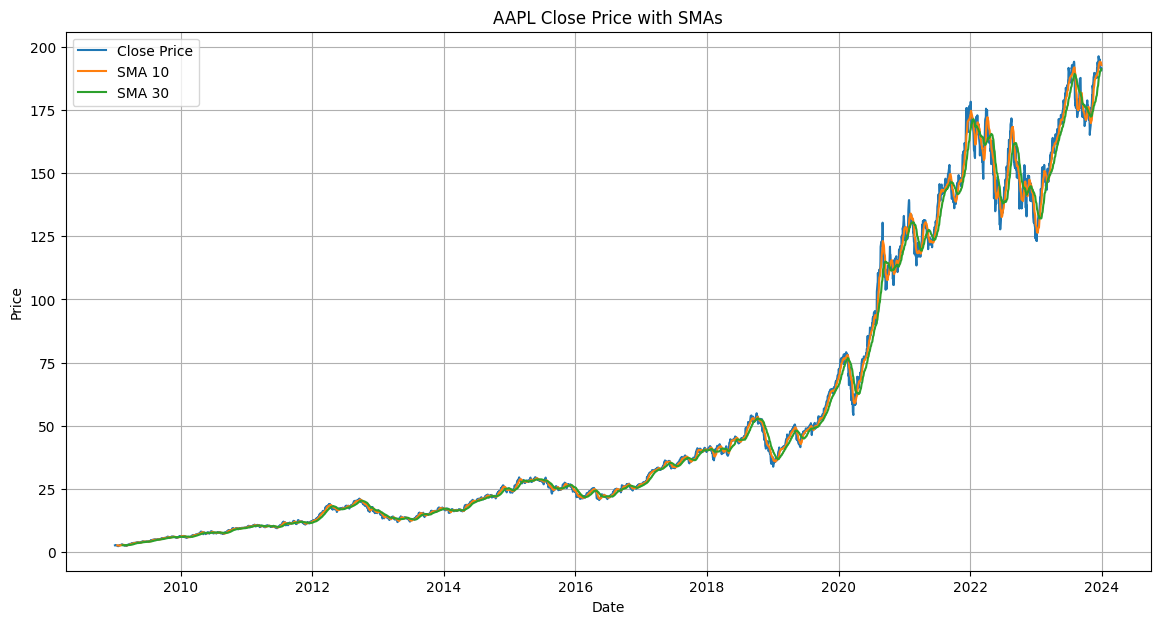

In [7]:
plt.figure(figsize=(14, 7))
plt.plot(aaple_df['Close'], label='Close Price')
plt.plot(aaple_df['SMA_10'], label='SMA 10')
plt.plot(aaple_df['SMA_30'], label='SMA 30')
plt.title('AAPL Close Price with SMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

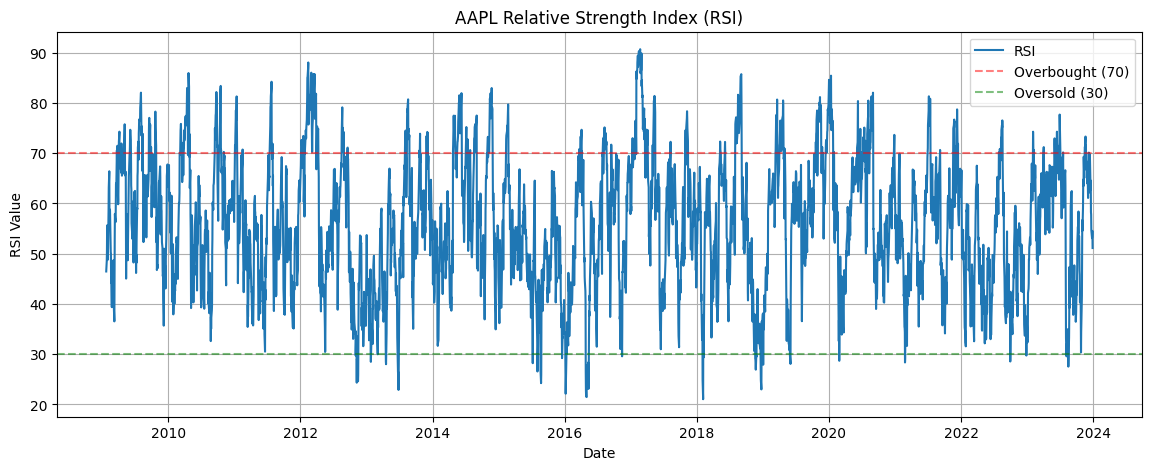

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(aaple_df['RSI'], label='RSI')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('AAPL Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True)
plt.show()

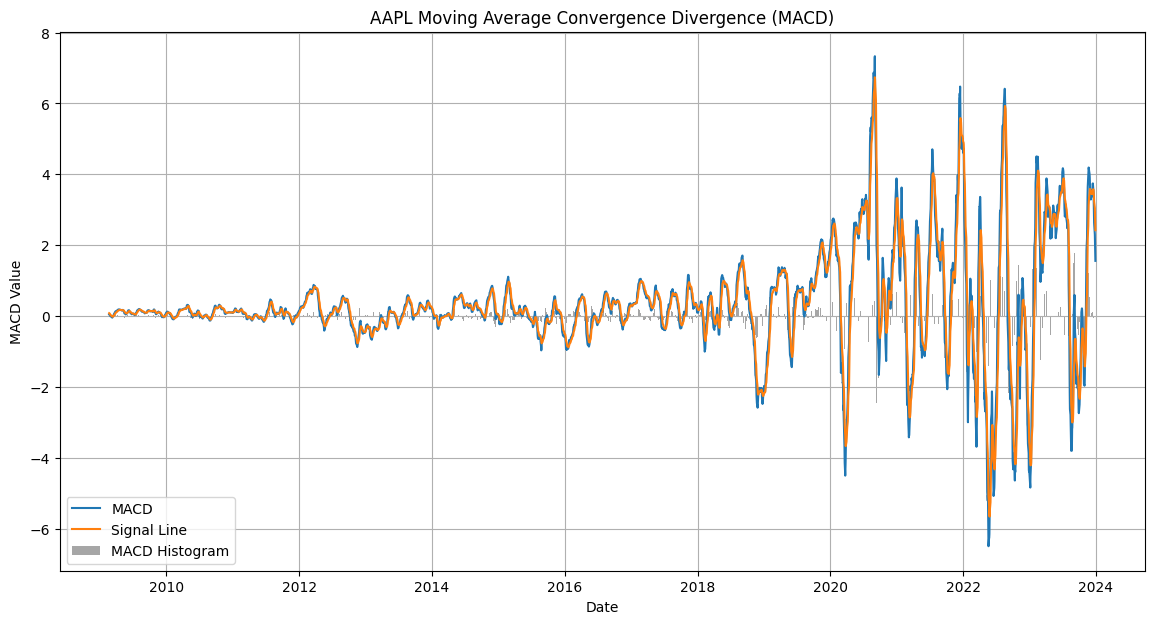

In [9]:
plt.figure(figsize=(14, 7))
plt.plot(aaple_df['MACD'], label='MACD')
plt.plot(aaple_df['MACD_Signal'], label='Signal Line')
plt.bar(aaple_df.index, aaple_df['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.7)
plt.title('AAPL Moving Average Convergence Divergence (MACD)')
plt.xlabel('Date')
plt.ylabel('MACD Value')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
!pip install pynance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.9 MB/s eta 0:00:00


### Understanding PyNance for Financial Metrics

While `TA-Lib` is excellent for calculating a wide array of technical indicators (like SMA, RSI, MACD), `PyNance` is a broader financial analysis framework. It focuses on object-oriented representations of financial instruments (like stocks), portfolios, and provides tools for tasks such as valuation, risk management, and constructing financial models rather than just adding indicator columns to a DataFrame.

For calculating additional *metrics* that extend beyond typical technical indicators but are often used in financial analysis, we can leverage pandas. Below, I will calculate **Daily Returns** and **Historical Volatility** for the Apple stock.

In [11]:
# Calculate Daily Returns
aaple_df['Daily_Return'] = aaple_df['Close'].pct_change() * 100

# Calculate Historical Volatility (e.g., 20-day rolling standard deviation of daily returns)
aaple_df['Volatility_20_Day'] = aaple_df['Daily_Return'].rolling(window=20).std()

# Display the DataFrame with new metrics
display(aaple_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,RSI,MACD,MACD_Signal,MACD_Hist,Daily_Return,Volatility_20_Day
Date,,,,,,,,,,,,,
2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,193.915672,190.295857,54.672784,2.633141,3.235256,-0.602115,-0.554751,0.907145
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,193.902795,190.515450,53.090049,2.304751,3.049155,-0.744404,-0.284086,0.910251
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,193.748254,190.791179,53.354446,2.029104,2.845145,-0.816041,0.051798,0.908625
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,193.314354,190.993931,54.540999,1.823998,2.640915,-0.816918,0.222626,0.897325
2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.761572,191.143189,51.121347,1.559539,2.424640,-0.865101,-0.542411,0.907751


### Understanding the Financial Metrics: Deeper Insights

1.  **Daily Returns (`aaple_df['Daily_Return']`)**:
    *   **What it is**: This metric quantifies the percentage change in Apple's stock price from one closing day to the next. It's calculated by `(Current_Close - Previous_Close) / Previous_Close * 100`.
    *   **Why it's important**: Daily returns are the most fundamental measure of a stock's performance. They directly indicate the profit or loss an investor would realize on a daily basis. Analyzing daily returns helps identify short-term price movements, assess market reactions to news, and forms the basis for more complex risk and return calculations. Positive returns signal growth, while negative returns indicate a decline.
    *   **Insight**: Consistent positive daily returns, even small ones, compound significantly over time. Conversely, large negative returns can quickly erode capital. Understanding the distribution and frequency of these returns is crucial for risk management and portfolio construction.

2.  **Historical Volatility (`aaple_df['Volatility_20_Day']`)**:
    *   **What it is**: This metric measures the *dispersion* or *spread* of the daily returns over a specified period, in this case, a 20-day rolling window. It's calculated as the standard deviation of the daily returns within that window.
    *   **Why it's important**: Volatility is a key indicator of **risk**. A higher volatility means the stock price experiences larger and more frequent fluctuations, implying greater uncertainty and potential for both larger gains and larger losses. Conversely, lower volatility suggests a more stable and predictable price movement.
    *   **Insight**: For traders, high volatility can present more opportunities for short-term profits but also carries higher risk. For long-term investors, extreme volatility might be a concern as it indicates potential for significant drawdowns. The 20-day period is a common choice for assessing short-to-medium term price instability, helping to understand the recent 'choppiness' of the stock.

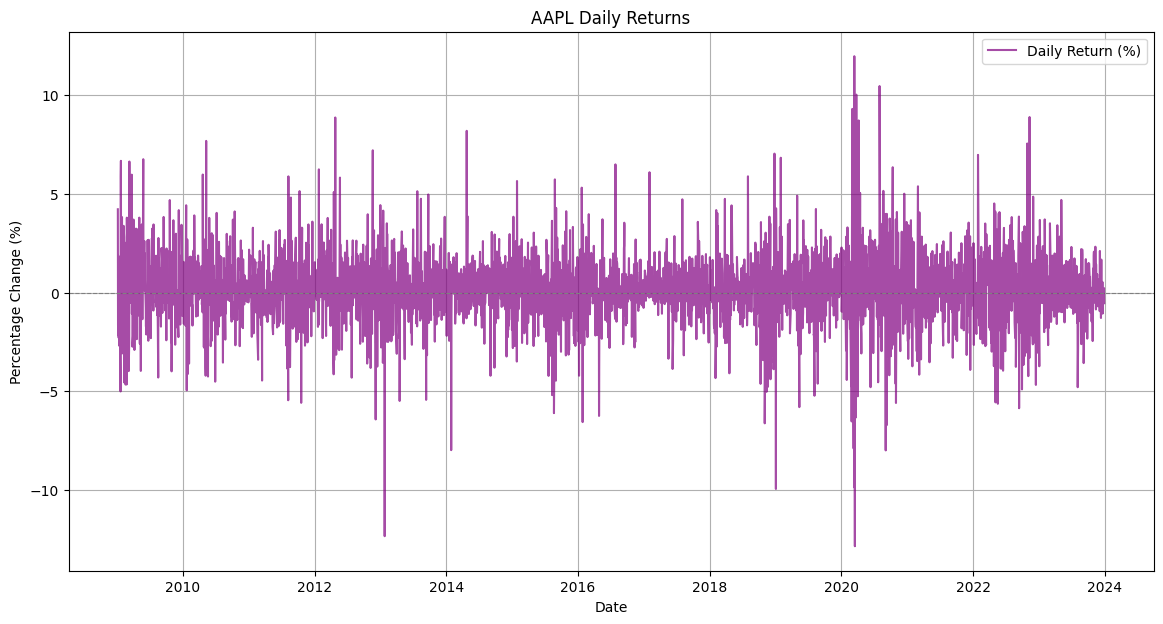

In [12]:
plt.figure(figsize=(14, 7))
plt.plot(aaple_df['Daily_Return'], label='Daily Return (%)', color='purple', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.legend()
plt.grid(True)
plt.show()

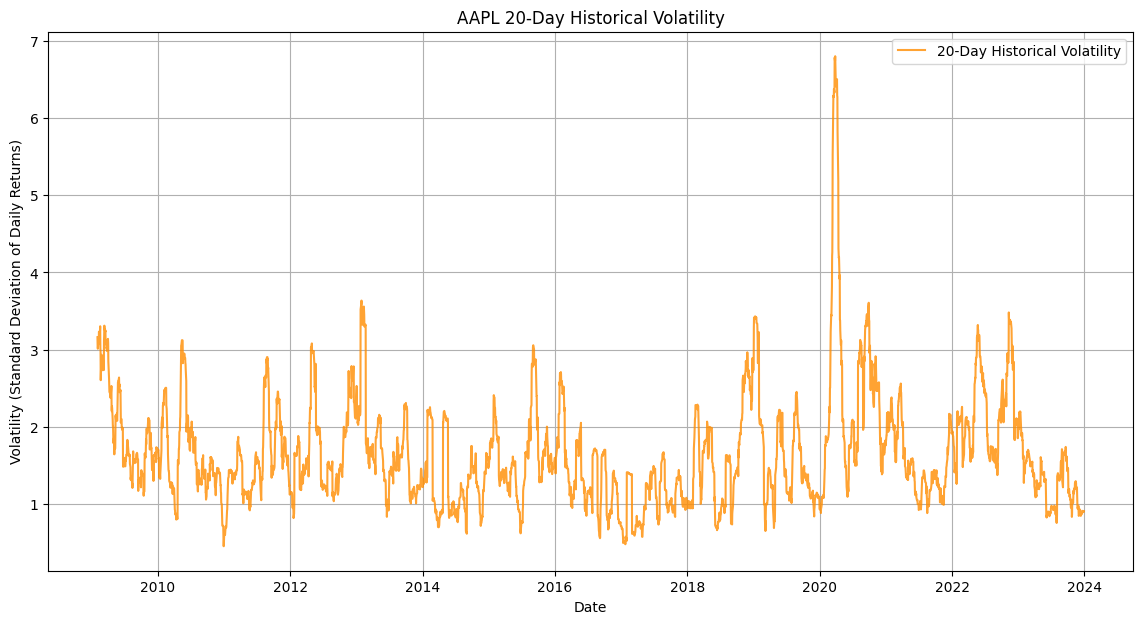

In [13]:
plt.figure(figsize=(14, 7))
plt.plot(aaple_df['Volatility_20_Day'], label='20-Day Historical Volatility', color='darkorange', alpha=0.8)
plt.title('AAPL 20-Day Historical Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.legend()
plt.grid(True)
plt.show()

### Insights from Visualizations:

1.  AAPL Daily Returns Plot :
    *   **Observation**: The plot shows frequent fluctuations around the zero line, indicating that daily price changes are common. There are periods of higher volatility (larger spikes, both positive and negative) and periods of relative calm.
    *   **Interpretation**: The stock exhibits typical market behavior, with daily gains and losses. The magnitude of these changes is key. Large positive spikes might correspond to positive news (e.g., strong earnings report, new product launch), while large negative spikes could be due to adverse events (e.g., market downturn, negative company news).
    *   **Actionable Insight**: For short-term traders, these fluctuations represent opportunities. For long-term investors, the overall trend and the frequency/magnitude of extreme movements are more important than individual daily wiggles.

2.  AAPL 20-Day Historical Volatility Plot
:
    *   **Observation**: This plot clearly illustrates periods where the 20-day rolling volatility is high and periods where it's low. Peaks in the volatility line suggest times of increased market uncertainty or rapid price swings, while troughs indicate more stable price action.
    *   Interpretation: Higher volatility means higher risk. When the volatility line is climbing, it implies that Apple's stock price is becoming more unpredictable, potentially offering larger gains but also exposing investors to greater potential losses. Conversely, low volatility suggests a more predictable and less risky environment.
    *   **Actionable Insight**: Periods of rising volatility might warrant caution for risk-averse investors or suggest opportunities for those employing volatility-based strategies. Conversely, periods of low volatility can lead to complacency, but also might precede a significant move. Understanding these trends helps in adjusting risk exposure and managing expectations.